In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
import xgboost as xgb

In [7]:
df = pd.read_csv('./data/train.csv')

In [8]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
df['MSZoning'].value_counts()


MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

<Axes: >

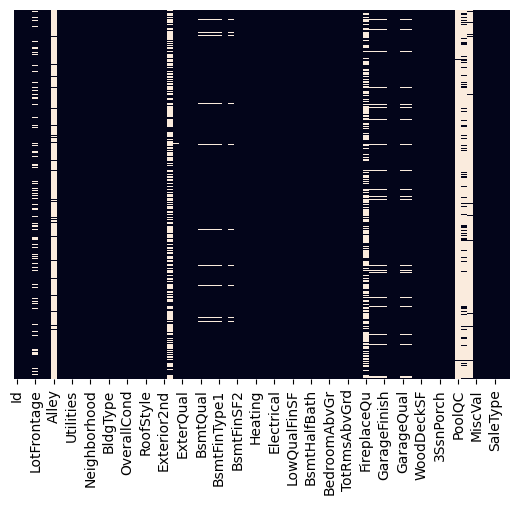

In [10]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False)


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [12]:
## Fill Missing Values

df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [13]:
df.drop(['Alley'],axis=1,inplace=True)


In [14]:
df['BsmtCond']=df['BsmtCond'].fillna(df['BsmtCond'].mode()[0])
df['BsmtQual']=df['BsmtQual'].fillna(df['BsmtQual'].mode()[0])

In [15]:
df['FireplaceQu']=df['FireplaceQu'].fillna(df['FireplaceQu'].mode()[0])
df['GarageType']=df['GarageType'].fillna(df['GarageType'].mode()[0])

In [16]:
df.drop(['GarageYrBlt'],axis=1,inplace=True)

In [17]:
df['GarageFinish']=df['GarageFinish'].fillna(df['GarageFinish'].mode()[0])
df['GarageQual']=df['GarageQual'].fillna(df['GarageQual'].mode()[0])
df['GarageCond']=df['GarageCond'].fillna(df['GarageCond'].mode()[0])

In [18]:
df.drop(['PoolQC','Fence','MiscFeature'],axis=1,inplace=True)


In [19]:
df.drop(['Id'],axis=1,inplace=True)


In [20]:
df.shape


(1460, 75)

In [21]:
df.isnull().sum()


MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 75, dtype: int64

In [22]:
df['MasVnrType']=df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['MasVnrArea']=df['MasVnrArea'].fillna(df['MasVnrArea'].mode()[0])

<Axes: >

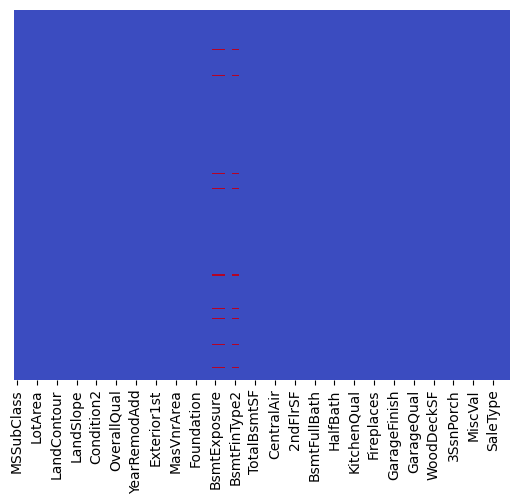

In [23]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')


In [24]:
df['BsmtExposure']=df['BsmtExposure'].fillna(df['BsmtExposure'].mode()[0])


<Axes: >

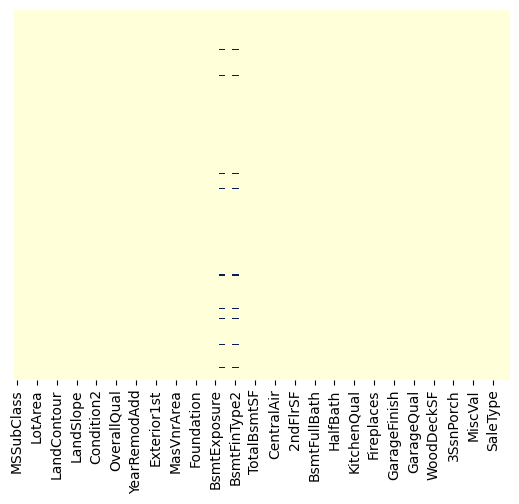

In [25]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='YlGnBu')


In [26]:
df['BsmtFinType2']=df['BsmtFinType2'].fillna(df['BsmtFinType2'].mode()[0])


In [27]:
df.dropna(inplace=True)


In [28]:
print(df.isnull().values.any())

False


In [29]:
df.shape

(1422, 75)

In [30]:
# Age maison
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

# Surface totale réelle
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Qualité globale non linéaire
df['OverallQual2'] = df['OverallQual'] ** 2

# Total salles de bain
df['TotalBath'] = (
    df['FullBath'] +
    0.5 * df['HalfBath'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

In [31]:
# df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

In [32]:
print(df.isnull().values.any())

False


In [33]:
##HAndle Categorical Features
categ_columns=[ 'MSZoning','Street','LotShape','LandContour','Utilities','LotConfig','LandSlope','Neighborhood',
    'Condition2','BldgType','Condition1','HouseStyle','SaleType','SaleCondition','ExterCond',
    'Foundation','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','CentralAir','Electrical',
    'Functional','GarageType','GarageFinish','PavedDrive', "Heating"]

In [34]:
ordinal_columns = ["ExterQual", "KitchenQual", "HeatingQC", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageQual", "GarageCond", "MasVnrType"]

In [35]:
for col in ordinal_columns:
    print(col, df[col].unique())

ExterQual <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str
KitchenQual <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str
HeatingQC <StringArray>
['Ex', 'Gd', 'TA', 'Fa', 'Po']
Length: 5, dtype: str
BsmtQual <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str
BsmtCond <StringArray>
['TA', 'Gd', 'Fa', 'Po']
Length: 4, dtype: str
BsmtExposure <StringArray>
['No', 'Gd', 'Mn', 'Av']
Length: 4, dtype: str
BsmtFinType1 <StringArray>
['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', 'LwQ']
Length: 6, dtype: str
BsmtFinType2 <StringArray>
['Unf', 'BLQ', 'ALQ', 'Rec', 'LwQ', 'GLQ']
Length: 6, dtype: str
FireplaceQu <StringArray>
['Gd', 'TA', 'Fa', 'Ex', 'Po']
Length: 5, dtype: str
GarageQual <StringArray>
['TA', 'Fa', 'Gd', 'Ex', 'Po']
Length: 5, dtype: str
GarageCond <StringArray>
['TA', 'Fa', 'Gd', 'Po', 'Ex']
Length: 5, dtype: str
MasVnrType <StringArray>
['BrkFace', 'Stone', 'BrkCmn']
Length: 3, dtype: str


In [36]:
qual_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
bsmt_exp_map = {'Gd':4,'Av':3,'Mn':2,'No':1,'None':0}
bsmt_fin_map = {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'None':0}
masvnr_map = {'BrkFace':3,'Stone':2,'BrkCmn':1,'None':0}

# Appliquer aux colonnes ordinales
ordinal_catg_columns = {
    'ExterQual': qual_map,
    'KitchenQual': qual_map,
    'HeatingQC': qual_map,
    'BsmtQual': qual_map,
    'BsmtCond': qual_map,
    'FireplaceQu': qual_map,
    'GarageQual': qual_map,
    'GarageCond': qual_map,
    'BsmtExposure': bsmt_exp_map,
    'BsmtFinType1': bsmt_fin_map,
    'BsmtFinType2': bsmt_fin_map,
    'MasVnrType': masvnr_map
}

for col in ordinal_catg_columns.keys():
    df[col] = df[col].fillna('None') 



In [37]:
for col, mapping in ordinal_catg_columns.items():
    df[col] = df[col].map(mapping)

In [38]:
print(df.isnull().values.any())

False


In [39]:
def category_onehot_multcols(multcolumns):
    df_final=final_df
    i=0
    for fields in multcolumns:
        
        print(fields)
        df1=pd.get_dummies(final_df[fields],drop_first=True)
        
        final_df.drop([fields],axis=1,inplace=True)
        if i==0:
            df_final=df1.copy()
        else:
            
            df_final=pd.concat([df_final,df1],axis=1)
        i=i+1
       
        
    df_final=pd.concat([final_df,df_final],axis=1)
        
    return df_final

In [40]:
main_df=df.copy()


In [41]:
## Combine Test Data 

test_df=pd.read_csv('formulatedtest_1.csv')

In [42]:
test_df.shape


(1459, 79)

In [43]:
test_df.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,HouseAge,RemodAge,TotalSF,OverallQual2,TotalBath
0,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,6,2010,WD,Normal,49,49,1778.0,25,1.0
1,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,12500,6,2010,WD,Normal,52,52,2658.0,36,1.5
2,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,3,2010,WD,Normal,13,12,2557.0,25,2.5
3,60,RL,78.0,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,6,2010,WD,Normal,12,12,2530.0,36,2.5
4,120,RL,43.0,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,...,0,1,2010,WD,Normal,18,18,2560.0,64,2.0


In [44]:
final_df=pd.concat([df,test_df],axis=0)


In [45]:
print(final_df.isnull().values.any())

True


In [46]:
final_df['SalePrice']


0       208500.0
1       181500.0
2       223500.0
3       140000.0
4       250000.0
          ...   
1454         NaN
1455         NaN
1456         NaN
1457         NaN
1458         NaN
Name: SalePrice, Length: 2881, dtype: float64

In [47]:
final_df.shape


(2881, 80)

In [48]:
final_df=category_onehot_multcols(categ_columns)


MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition2
BldgType
Condition1
HouseStyle
SaleType
SaleCondition
ExterCond
Foundation
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
CentralAir
Electrical
Functional
GarageType
GarageFinish
PavedDrive
Heating


In [49]:
final_df.shape


(2881, 208)

In [50]:
final_df =final_df.loc[:,~final_df.columns.duplicated()]


In [51]:
print(final_df.isnull().values.any())

True


In [52]:
final_df.shape


(2881, 185)

In [53]:
final_df

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrType,MasVnrArea,ExterQual,...,BuiltIn,CarPort,Detchd,RFn,Unf,P,GasW,Grav,OthW,Wall
0,60,65.0,8450,7,5,2003,2003,3,196.0,4,...,False,False,False,True,False,False,False,False,False,False
1,20,80.0,9600,6,8,1976,1976,3,0.0,3,...,False,False,False,True,False,False,False,False,False,False
2,60,68.0,11250,7,5,2001,2002,3,162.0,4,...,False,False,False,True,False,False,False,False,False,False
3,70,60.0,9550,7,5,1915,1970,3,0.0,3,...,False,False,True,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,3,350.0,4,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,21.0,1936,4,7,1970,1970,3,0.0,3,...,False,False,False,False,True,False,False,False,False,False
1455,160,21.0,1894,4,5,1970,1970,3,0.0,3,...,False,True,False,False,True,False,False,False,False,False
1456,20,160.0,20000,5,7,1960,1996,3,0.0,3,...,False,False,True,False,True,False,False,False,False,False
1457,85,62.0,10441,5,5,1992,1992,3,0.0,3,...,False,False,False,False,True,False,False,False,False,False


In [54]:
print(final_df.isnull().values.any())

True


In [55]:
df_Train=final_df.iloc[:1422,:]
df_Test=final_df.iloc[1422:,:]

In [56]:
df_Train.head()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrType,MasVnrArea,ExterQual,...,BuiltIn,CarPort,Detchd,RFn,Unf,P,GasW,Grav,OthW,Wall
0,60,65.0,8450,7,5,2003,2003,3,196.0,4,...,False,False,False,True,False,False,False,False,False,False
1,20,80.0,9600,6,8,1976,1976,3,0.0,3,...,False,False,False,True,False,False,False,False,False,False
2,60,68.0,11250,7,5,2001,2002,3,162.0,4,...,False,False,False,True,False,False,False,False,False,False
3,70,60.0,9550,7,5,1915,1970,3,0.0,3,...,False,False,True,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,3,350.0,4,...,False,False,False,True,False,False,False,False,False,False


In [57]:
df_Test.columns


Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       ...
       'BuiltIn', 'CarPort', 'Detchd', 'RFn', 'Unf', 'P', 'GasW', 'Grav',
       'OthW', 'Wall'],
      dtype='str', length=185)

In [58]:
df_Train.shape


(1422, 185)

In [59]:
df_Test.drop(['SalePrice'],axis=1,inplace=True)


In [60]:
X_train=df_Train.drop(['SalePrice'],axis=1)
y_train=df_Train['SalePrice']



In [61]:
X_train.shape

(1422, 184)

In [62]:
df_Test.shape

(1459, 184)

Prediciton and selecting the Algorithm


In [63]:
import xgboost
# raw_classifier = xgboost.XGBRegressor()

In [64]:
# raw_classifier.fit(X_train, y_train)

In [65]:
# import pickle
# filename = 'raw_classifer_model.pkl'
# pickle.dump(raw_classifier, open(filename, 'wb'))

In [66]:
# y_raw_classifier_pred = raw_classifier.predict(df_Test)

In [67]:
# y_raw_classifier_pred

In [68]:
# y_raw_classifier_pred_df=pd.DataFrame(y_raw_classifier_pred)


# sub_df=pd.read_csv('./data/sample_submission.csv')
# datasets=pd.concat([sub_df['Id'],y_raw_classifier_pred_df],axis=1)
# datasets.columns=['Id','SalePrice']
# datasets.to_csv('sample_submission_3.csv',index=False)

### Optimisation d'hyperparametre

In [69]:
regressor = xgboost.XGBRegressor()

In [70]:
booster=['gbtree','gblinear']
base_score=[0.25,0.5,0.75,1]

In [71]:
# ## Hyper Parameter Optimization
# n_estimators = [100, 500, 900, 1100, 1500]
# max_depth = [2, 3, 5, 10, 15]
# booster=['gbtree','gblinear']
# learning_rate=[0.05,0.1,0.15,0.20]
# min_child_weight=[1,2,3,4]

# # Define the grid of hyperparameters to search
# hyperparameter_grid = {
#     'n_estimators': n_estimators,
#     'max_depth':max_depth,
#     'learning_rate':learning_rate,
#     'min_child_weight':min_child_weight,
#     'booster':booster,
#     'base_score':base_score
#     }

In [72]:
# # Set up the random search with 4-fold cross validation

# random_cv = RandomizedSearchCV(estimator=regressor,
#             param_distributions=hyperparameter_grid,
#             cv=5, n_iter=50,
#             scoring = 'neg_mean_absolute_error',n_jobs = 4,
#             verbose = 5, 
#             return_train_score = True,
#             random_state=42)

In [73]:
# random_cv.fit(X_train,y_train)


In [74]:
# print(random_cv.best_estimator_)


In [75]:
import pickle

# filename = 'optimized_regressor_model.pkl'
# pickle.dump(random_cv.best_estimator_, open(filename, 'wb'))

In [76]:
# # Load the model from disk

with open("optimized_regressor_model.pkl", "rb") as f:
    optimized_regressor_model = pickle.load(f)



In [77]:
y_pred = optimized_regressor_model.predict(df_Test)

In [94]:
y_pred

array([122782.15, 159230.16, 186254.72, ..., 162747.8 , 119612.88,
       220214.58], shape=(1459,), dtype=float32)

In [ ]:
# # Predict on test set

# y_pred_df = pd.DataFrame(y_pred)


# sub_df=pd.read_csv('./data/sample_submission.csv')
# datasets=pd.concat([sub_df['Id'],y_pred_df],axis=1)
# datasets.columns=['Id','SalePrice']
# datasets.to_csv('submission_4.csv',index=False)


In [96]:
# Calcul des learning curves
from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    optimized_regressor_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

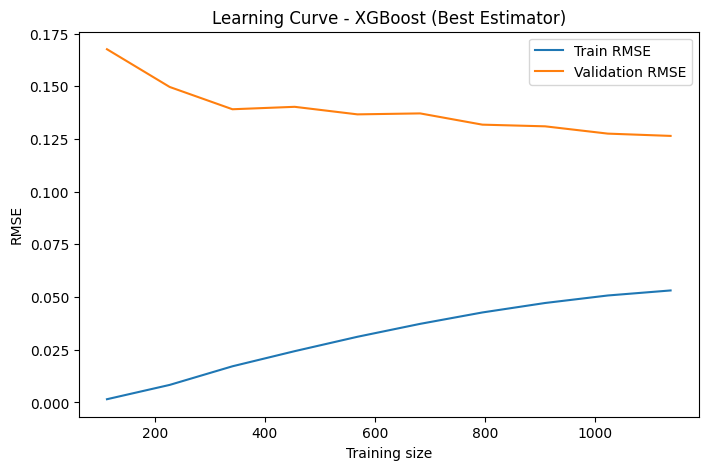

In [97]:
# Remettre en positif
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_rmse, label="Train RMSE")
plt.plot(train_sizes, val_rmse, label="Validation RMSE")
plt.xlabel("Training size")
plt.ylabel("RMSE")
plt.title("Learning Curve - XGBoost (Best Estimator)")
plt.legend()
plt.show()

#### Transformation logarithmique

In [82]:
# transformation log
y_train = np.log1p(df_Train['SalePrice'])
X_train = df_Train.drop(['SalePrice'], axis=1)

In [83]:
# regressor = xgboost.XGBRegressor(objective='reg:squarederror')


In [84]:
# hyperparameter_grid = {
#     'n_estimators': [500, 1000, 1500, 2000],
#     'max_depth': [3,4,5,6,8],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'min_child_weight': [1,2,3,5],
#     'subsample': [0.6,0.8,1.0],
#     'colsample_bytree': [0.6,0.8,1.0],
#     'gamma': [0,0.1,0.2,0.3],
#     'booster': ['gbtree'],
#     'reg_alpha': [0,0.01,0.1],
#     'reg_lambda': [1,1.5,2]
# }

In [85]:
# random_cv = RandomizedSearchCV(
#     estimator=regressor,
#     param_distributions=hyperparameter_grid,
#     cv=5,
#     n_iter=50,
#     scoring='neg_root_mean_squared_error',  # cohérent avec Kaggle
#     n_jobs=4,
#     verbose=2,
#     random_state=42
# )

In [86]:
# random_cv.fit(X_train, y_train)

In [87]:
# y_pred_log = random_cv.best_estimator_.predict(df_Test)
# y_pred = np.expm1(y_pred_log)  # retour à l’échelle normale

In [88]:
# model = random_cv.best_estimator_

# scores = cross_val_score(
#     model,
#     X_train,
#     y_train,
#     scoring='neg_root_mean_squared_error',
#     cv=5
# )

# rmse_log = -scores.mean()
# print("CV RMSE (log):", rmse_log)

In [89]:
# import pickle
# filename = 'optimized_regressor_model_2.pkl'
# pickle.dump(random_cv.best_estimator_, open(filename, 'wb'))

In [90]:
X_train.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('bool')], dtype=object)

In [91]:
# # Predict on test set

# y_pred_df = pd.DataFrame(y_pred)


# sub_df=pd.read_csv('./data/sample_submission.csv')
# datasets=pd.concat([sub_df['Id'],y_pred_df],axis=1)
# datasets.columns=['Id','SalePrice']
# datasets.to_csv('submission_5.csv',index=False)


In [92]:
X_train.select_dtypes(include='object')

""
0
1
2
3
4
...
1455
1456
1457
1458


In [93]:
X_train['Heating'] = X_train['Heating'].astype('category').cat.codes

KeyError: 'Heating'

In [ ]:
df_Test['Heating'] = df_Test['Heating'].astype('category').cat.codes

Feature Engineering

In [ ]:
dtrain = xgb.DMatrix(X_train, label=y_train)

In [ ]:
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.03,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.01,
    'reg_lambda': 1,
    'seed': 42
}

In [ ]:


model = xgb.train(
    params,
    dtrain,
    num_boost_round=5000,
    evals=[(dtrain, 'train')],
    early_stopping_rounds=200,
    verbose_eval=False
)

In [ ]:
dtest = xgb.DMatrix(df_Test)  # test_df doit être sans la colonne cible


In [ ]:
y_pred = model.predict(dtest)
y_pred = np.expm1(y_pred)  # retour à l’échelle normale

In [ ]:
y_pred

array([121867.766, 164846.86 , 184080.81 , ..., 162718.25 , 115061.71 ,
       216718.42 ], shape=(1459,), dtype=float32)

In [ ]:
# model = xgb.XGBRegressor(
#     n_estimators=5000,
#     learning_rate=0.03,
#     max_depth=4,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.01,
#     reg_lambda=1,
#     random_state=42,
#     objective='reg:squarederror'
# )

In [ ]:
# model.fit(
#     X_train, y_train,
#     eval_set=[(X_train, y_train)],
#     verbose=False
# )

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
# y_pred = model.predict(df_Test)
# y_pred = np.expm1(y_pred)  # retour à l’échelle normale

In [ ]:
# scores = cross_val_score(
#     model,
#     X_train,
#     y_train,
#     scoring='neg_root_mean_squared_error',
#     cv=5
# )

# rmse_log = -scores.mean()
# print("CV RMSE (log):", rmse_log)

CV RMSE (log): 0.12543642856699647


In [ ]:
# # Predict on test set

# y_pred_df = pd.DataFrame(y_pred)


# sub_df=pd.read_csv('./data/sample_submission.csv')
# datasets=pd.concat([sub_df['Id'],y_pred_df],axis=1)
# datasets.columns=['Id','SalePrice']
# datasets.to_csv('submission_6.csv',index=False)
